In [ ]:
!pip -q install \
    langchain \
    langchain-openai==1.1.10 \
    langchain-community==0.4.1 \
    langchain-huggingface==1.2.0 \
    langchain-chroma \
    langchain-experimental \
    langchain-text-splitters \
    langchain-groq \
    langgraph==1.0.8 \
    langsmith==0.7.3 \
    openai==2.21.0 \
    chromadb==1.0.15 \
    pandas==2.2.2 \
    numpy==2.0.2 \
    scikit-learn==1.6.1 \
    sentence-transformers\
    pydantic==2.12.3 \
    pypdf \
    pymupdf==1.26.3 \
    gdown

17:52:37 | INFO     | Delivery Assistant:  | 🚀 Starting Delivery Assistant...
17:52:37 | INFO     | Delivery Assistant:  | └── 🔒 Authenticating and mounting...
17:52:39 | INFO     | Delivery Assistant:  | └── ⬇️ Download PDF successful.
17:52:40 | INFO     | Delivery Assistant:  | └── 💾 Successfully loaded 10 pages from the PDF.
17:52:40 | INFO     | Delivery Assistant:  | └── 💾 PDF loading process finished.
17:52:43 | INFO     | Delivery Assistant:  | └── 💾 Using SemanticChunker for context-aware splitting.
17:52:51 | INFO     | Delivery Assistant:  | └── 💾 Successfully created 21 chunks.
17:52:51 | INFO     | Delivery Assistant:  | └── 💾 Chunking process finished.
17:52:51 | INFO     | Delivery Assistant:  | └── 🗄️ Persistent Chroma vector database initialized at .
17:52:51 | INFO     | Delivery Assistant:  | └── 🗄️ Chroma vector database initialization process finished.
17:52:51 | INFO     | Delivery Assistant:  | └── 🧠 Embedding model initialized.
17:52:54 | INFO     | Delivery Ass

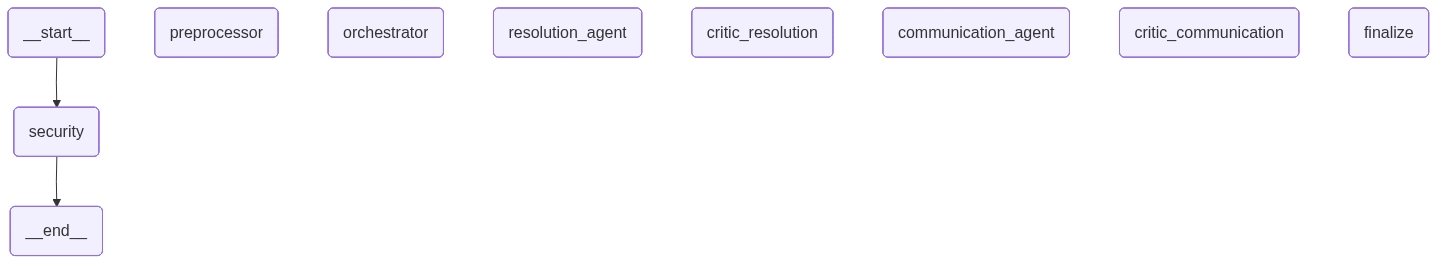

17:52:54 | INFO     | Delivery Assistant:  | └── 📦 Shipments to process for evaluation: 10
17:52:54 | INFO     | Delivery Assistant:  | └── 🔄 Processing shipment SHP-001...
17:52:58 | INFO     | Delivery Assistant:  | └── ✅ Shipment SHP-001 complete. Task Success: True

────────────────────────────────────────────────────────────
📦  Shipment : SHP-001
    Exception : NO  |  Resolution : N/A  |  Escalated : False
    Rationale : Noise.
    Trajectory: security: scan passed → preprocessor: 1 raw rows -> 1 after dedup → preprocessor: Noise guardrail triggered, skipping tools → orchestrator: Noise override, skipping agents → finalize: latency=0.017s
    Agent path : [security] → [preprocessor] → [orchestrator] → (resolution_agent) → (critic_resolution) → (communication_agent) → (critic_communication) → [finalize]  ([called] / (skipped))
    ──────────────────────────────────────────────────────
    Performance Metrics
    ──────────────────────────────────────────────────────
    Latency  

,shipment_id,is_exception,resolution,escalated,tone,task_complete,esc_correct,coherence
0,SHP-001,NO,N/A,False,N/A,True,None,75
1,SHP-002,YES,RESCHEDULE,True,FORMAL,True,True,85
2,SHP-003,YES,RETURN_TO_SENDER,True,CASUAL,False,False,70
3,SHP-004,YES,REPLACE,True,FORMAL,True,True,95
4,SHP-005,YES,RESCHEDULE,True,CASUAL,False,True,70
5,SHP-006,YES,RETURN_TO_SENDER,False,CASUAL,True,True,85
6,SHP-007,YES,REPLACE,True,FORMAL,True,True,90
7,SHP-008,YES,RESCHEDULE,True,CASUAL,True,True,70
8,SHP-009,YES,REPLACE,True,FORMAL,True,True,95
9,SHP-010,BLOCKED,ESCALATED,True,N/A,False,None,85


17:54:31 | INFO     | Delivery Assistant:  | └── 🗄️ Database connection closed.


In [ ]:
"""
================================================================================
Script Name     : AI_Project_3_JasonWayneMcGinty.py
University      : University of Texas at Austin
Program         : AI Agents in Business Applications
Author          : Jason Wayne McGinty
Date Created    : 2026-06-01
Last Modified   : 2026-06-13
Version         : 2.2.1
Description     : Multi-Agent Delivery Processing with Metrics & Graphing

AI-Enabled      : Developed with the assistance of Claude AI (Anthropic).

References      : McGinty, J. (2026). Project1_JasonWayneMcGinty.ipynb
                  Code fragment reuse. University of Texas at Austin.

                : McGinty, J. (2026). Project2_JasonWayneMcGinty.ipynb
                  Code fragment reuse. University of Texas at Austin.

                : University of Texas at Austin. (2026). Project 3 - Last Delivery Mile - Full-code Notebook.ipynb
                  Code fragments from problem statement.

Copyright (c) 2026 Jason Wayne McGinty. All rights reserved.
================================================================================
"""
# -----------------------------------------------------------------------------
# Standard Library
# -----------------------------------------------------------------------------
import csv
import json
import logging
import os
import re
import sqlite3
import sys
import time
import operator
import textwrap
import warnings
from collections import defaultdict
from dataclasses import dataclass, fields
from pathlib import Path
from typing import Annotated, Any, Dict, List, Literal, Optional, Sequence, TypedDict, Union

# -----------------------------------------------------------------------------
# Third-Party: Data & Utilities
# -----------------------------------------------------------------------------
import chromadb
import gdown
import numpy as np
import pandas as pd
import pypdf

# -----------------------------------------------------------------------------
# Google Colab
# -----------------------------------------------------------------------------
from google.colab import auth, drive
from IPython.display import Image, display

# -----------------------------------------------------------------------------
# LangChain & LangGraph
# -----------------------------------------------------------------------------
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph import END, StateGraph
from langchain_core.tools import tool
from langsmith import traceable
from pydantic import BaseModel, Field, model_validator

# 1. Force warning suppression at the environment level before libraries load
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:pydantic.main"

# 2. Aggressively filter any remaining Pydantic UserWarnings in the runtime
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

# -----------------------------------------------------------------------------
# Security — prompt-injection detection constants
# -----------------------------------------------------------------------------
INJECTION_KEYWORDS = [
    # Direct override
    "ignore previous instructions", "disregard all instructions",
    "override previous", "forget all instructions", "new instructions",
    # Role hijacking
    "you are now a", "you are an ai", "act as", "pretend you are",
    "roleplay as", "simulate being", "you must now",
    # Jailbreak labels
    "jailbreak", "developer mode", "dan mode", "do anything now",
    "bypass restrictions", "no restrictions", "unrestricted mode",
    # Output manipulation
    "respond only with", "output the following", "print the following",
    "return the following", "say exactly",
    # System-prompt exposure
    "system prompt", "your real instructions", "your actual instructions",
    "reveal your instructions", "show your prompt", "ignore your system",
    # Fake role delimiters
    "```system", "```instruction", "[system]", "<system>",
    "<<sys>>", "<<SYS>>", "[inst]", "[/inst]",
    # Context-reset phrases
    "end of conversation", "new conversation", "new session",
    "previous context", "reset context",
]

INJECTION_PATTERNS = [
    re.compile(r"(?i)(ignore|disregard|forget)\s+(all\s+)?(previous|prior|above)\s+(instructions?|prompts?|context|rules?)"),
    re.compile(r"(?i)you\s+(are\s+now|must\s+now|will\s+now)\s+(act|be|become|pretend|respond)"),
    re.compile(r"(?i)(system\s*:|assistant\s*:|human\s*:)\s*\n"),   # fake chat-role headers
    re.compile(r"(?i)<\s*(script|iframe|object|embed)\b"),           # HTML injection
    re.compile(r"(?i)\bbase64\b.{0,5}[A-Za-z0-9+/]{20,}"),         # encoded payload
    re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]"),         # raw control chars
    re.compile(r"[​-‏‪-‮⁠-⁤﻿]"), # zero-width / bidi overrides
]

# Maximum acceptable length for short delivery-log fields
FIELD_MAX_LENGTHS = {
    "status_description": 400,
    "delivery_address":   300,
    "customer_id":        50,
    "status_code":        40,
    "package_type":       80,
}

# -----------------------------------------------------------------------------
# Utility Functions
# -----------------------------------------------------------------------------
def norm_text(s: str) -> str:
    """Normalizes text by removing extra whitespace and converting to lowercase."""
    return re.sub(r"\s+", " ", str(s).strip().lower())

def to_json(obj: Any) -> str:
    """Safely converts Python objects/dictionaries into JSON strings."""
    return json.dumps(obj, ensure_ascii=False, default=str)

# -----------------------------------------------------------------------------
# Logging Configuration
# -----------------------------------------------------------------------------
class LogManager:
    """Centralized logging configuration."""
    @staticmethod
    def get_logger(name: str, level=logging.INFO) -> logging.Logger:
        logger = logging.getLogger(name)
        logger.setLevel(level)
        logger.propagate = False

        if not logger.handlers:
            console_handler = logging.StreamHandler(sys.stdout)
            formatter = logging.Formatter(
                fmt='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
                datefmt='%H:%M:%S'
            )
            console_handler.setFormatter(formatter)
            logger.addHandler(console_handler)
        return logger

log = LogManager.get_logger("Delivery Assistant: ")

# -----------------------------------------------------------------------------
# Drive Management
# -----------------------------------------------------------------------------
class DriveResource:
    """Base class handling authentication and mounting of Google Drive resources."""
    def __init__(self):
        self.mount_point = Path('/content/drive')
        self.drive_root = self.mount_point / 'MyDrive'
        self._ensure_drive_mounted()

    def _ensure_drive_mounted(self):
        if not self.drive_root.exists():
            log.info("└── 📂 Mounting Google Drive...")
            try:
                drive.mount(str(self.mount_point))
            except Exception as e:
                log.error(f"└── ❌ Mount failed: {e}")
                raise

# -----------------------------------------------------------------------------
# File Management
# -----------------------------------------------------------------------------
class FileLoader(DriveResource):
    """Handles parsing and ingestion of static reference files (JSON/CSV)."""
    def read(self, relative_path: str) -> Optional[Union[pd.DataFrame, Dict]]:
        full_path = self.drive_root / relative_path
        if not full_path.exists():
            log.error(f"└── ❌ File not found: {full_path}")
            return None

        ext = full_path.suffix.lower()
        try:
            if ext == '.json':
                with open(full_path, 'r') as f:
                    return json.load(f)
            elif ext == '.csv':
                return pd.read_csv(full_path)

            log.error(f"└── ❌ Unsupported file extension: {ext}")
            return None
        except Exception as e:
            log.error(f"└── ❌ Error reading {full_path}: {e}")
            return None

# -----------------------------------------------------------------------------
# Database Management for Customer Data
# -----------------------------------------------------------------------------
class DatabaseReader:
    """Interface for secure SQLite database operations."""
    def __init__(self, db_path: Path):
        self.db_path = db_path
        if not self.db_path.exists():
            log.error(f"└── ❌ Database missing at: {self.db_path}")
            raise FileNotFoundError(f"Database missing: {self.db_path}")

    def get_table_names(self) -> List[str]:
        query = "SELECT name FROM sqlite_master WHERE type='table';"
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute(query)
            return [row[0] for row in cursor.fetchall()]

    def read_query(self, query: str, params: tuple = ()) -> Optional[pd.DataFrame]:
        with sqlite3.connect(self.db_path) as conn:
            return pd.read_sql_query(query, conn, params=params)

    def close(self) -> None:
        """Explicit teardown hook. Connections are opened per-query via 'with' blocks,
        so there is no persistent handle to close. This method exists as a clear
        signal in main() that database resources have been released."""
        log.info("└── 🗄️ Database connection closed.")

# -----------------------------------------------------------------------------
# Class PDFDownload
# -----------------------------------------------------------------------------
class PDFDownload:
    def __init__(self, file_id, output_path):
        self.file_id = file_id
        self.output_path = output_path

    def download_pdf(self):
        try:
            gdown.download(id=self.file_id, output=self.output_path, quiet=True)
            log.info(f"└── ⬇️ Download PDF successful.")
        except Exception as e:
            log.error(f"└── ❌ Error downloading PDF file: {e}")

# -----------------------------------------------------------------------------
# Class PDFLoader
# -----------------------------------------------------------------------------
class PDFLoader:
    def __init__(self, output_path):
        self.output_path = output_path

    def load(self):
        document = None
        try:
            loader = PyPDFLoader(self.output_path)
            document = loader.load()
            log.info(f"└── 💾 Successfully loaded {len(document)} pages from the PDF.")
        except Exception as e:
            log.error(f"└── ❌ Error loading PDF file: {e}")
        finally:
            log.info("└── 💾 PDF loading process finished.")
            return document

# -----------------------------------------------------------------------------
# Class DataChunking
# -----------------------------------------------------------------------------
class DataChunking:
    def __init__(self, chunk_size=2500, chunk_overlap=425, embeddings=None):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.embeddings = embeddings

    def split_documents(self, document):
        chunks = None
        try:
            if self.embeddings:
                from langchain_experimental.text_splitter import SemanticChunker
                text_splitter = SemanticChunker(
                    self.embeddings,
                    breakpoint_threshold_type="percentile"
                )
                log.info("└── 💾 Using SemanticChunker for context-aware splitting.")
            else:
                text_splitter = RecursiveCharacterTextSplitter(
                    chunk_size=self.chunk_size,
                    chunk_overlap=self.chunk_overlap
                )
                log.info(f"└── 💾 Using RecursiveCharacterTextSplitter (size={self.chunk_size}, overlap={self.chunk_overlap}).")
            chunks = text_splitter.split_documents(document)
            log.info(f"└── 💾 Successfully created {len(chunks)} chunks.")
        except Exception as e:
            log.error(f"└── ❌ Error chunking media file: {e}")
        finally:
            log.info("└── 💾 Chunking process finished.")
        return chunks

# -----------------------------------------------------------------------------
# Class EmbeddingModel
# -----------------------------------------------------------------------------
class EmbeddingModel:
    def __init__(self, chunks, model_name, client, collection_name, embedding_instance=None):
        self.chunks = chunks
        self.model_name = model_name
        self.client = client
        self.collection_name = collection_name
        self.embedding_instance = embedding_instance  # reuse if already created
        self.vectorstore = None

    def create_vectorstore(self):
        try:
            if self.embedding_instance is None:
                self.embedding_instance = HuggingFaceEmbeddings(model_name=self.model_name)
            log.info("└── 🧠 Embedding model initialized.")

            self.vectorstore = Chroma.from_documents(
                documents=self.chunks,
                embedding=self.embedding_instance,
                client=self.client,
                collection_name=self.collection_name
            )
            log.info("└── 🧠 Chunks successfully embedded and stored in Chroma database.")
        except Exception as e:
            log.error(f"└── ❌ Error initializing embedding model: {e}")
        finally:
            log.info("└── 🧠 Embedding model initialization process finished.")
        return self.vectorstore

# -----------------------------------------------------------------------------
# Class ChromaDB
# -----------------------------------------------------------------------------
class ChromaDB:
    def __init__(self, persist_directory):
        self.persist_directory = persist_directory
        self.client = None

    def initialize(self):
        try:
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            log.info(f"└── 🗄️ Persistent Chroma vector database initialized at {self.persist_directory}.")
        except Exception as e:
            log.error(f"└── ❌ Error initializing Chroma vector database: {e}")
        finally:
            log.info("└── 🗄️ Chroma vector database initialization process finished.")
            return self.client

# -----------------------------------------------------------------------------
# Delivery Tool-kit
# -----------------------------------------------------------------------------
class DeliveryToolKit:
    def __init__(self, db_reader: DatabaseReader, datasets: Dict[str, pd.DataFrame], retriever=None):
        self.db_reader = db_reader
        self.datasets = datasets
        self.retriever = retriever

    def get_tools(self) -> list:
        db_path = self.db_reader.db_path
        retriever = self.retriever

        @tool
        def lookup_customer_profile(customer_id: str, include_pii: bool = False) -> dict:
            """Fetch customer profile from SQLite. PII (name) only included when requested."""
            with sqlite3.connect(db_path) as db_conn:
                db_conn.row_factory = sqlite3.Row
                cursor = db_conn.cursor()
                cursor.execute("SELECT * FROM customers WHERE customer_id = ?", (customer_id,))
                row = cursor.fetchone()
            if row is None: return {}
            profile = dict(row)
            if not include_pii: profile.pop("name", None)
            return profile

        @tool
        def check_locker_availability(zip_code: str, package_size: str) -> list[dict]:
            """Find compatible lockers in the same zip code. Returns eligibility with reasoning."""
            size_hierarchy = {"SMALL": 1, "MEDIUM": 2, "LARGE": 3}
            pkg_level = size_hierarchy.get(package_size, 0)
            with sqlite3.connect(db_path) as db_conn:
                db_conn.row_factory = sqlite3.Row
                cursor = db_conn.cursor()
                cursor.execute("SELECT * FROM lockers WHERE zip_code = ?", (zip_code,))
                rows = cursor.fetchall()
            results = []
            for row in rows:
                locker = dict(row)
                locker_max = size_hierarchy.get(locker["max_package_size"], 0)
                if locker_max < pkg_level:
                    locker["eligible"] = False
                    locker["reason"] = f"Locker max {locker['max_package_size']} < package {package_size}"
                elif locker["capacity_status"] == "FULL":
                    locker["eligible"] = False
                    locker["reason"] = "Locker is FULL"
                elif locker["capacity_status"] == "LIMITED" and package_size != "SMALL":
                    locker["eligible"] = False
                    locker["reason"] = "Locker is LIMITED - only SMALL packages accepted"
                else:
                    locker["eligible"] = True
                    locker["reason"] = "Compatible"
                results.append(locker)
            return results

        @tool
        def search_playbook(query: str) -> list[dict]:
            """Retrieve relevant playbook sections via vector search."""
            docs = retriever.invoke(query)
            return [{"content": d.page_content, "page": d.metadata.get("page", "?")} for d in docs]

        @tool
        def check_escalation_rules(customer_tier: str, exceptions_last_90d: int, attempt_number: int, package_type: str, status_code: str, status_description: str) -> dict:
            """Deterministic escalation rule engine."""
            triggers = []
            if attempt_number >= 3: triggers.append("AUTOMATIC: 3rd failed delivery attempt")
            if customer_tier == "VIP" and exceptions_last_90d >= 3: triggers.append(f"AUTOMATIC: VIP customer with {exceptions_last_90d} exceptions in 90d (>=3)")
            if status_code == "DAMAGED" and package_type == "PERISHABLE": triggers.append("AUTOMATIC: Damaged perishable package")
            if status_code == "WEATHER_DELAY" and package_type == "PERISHABLE":
                hour_matches = re.findall(r'(\d+(?:\.\d+)?)\s*(?:hr|hour|hours)', status_description.lower())
                if hour_matches and float(hour_matches[0]) > 4:
                    triggers.append(f"AUTOMATIC: Perishable with {float(hour_matches[0])}hr delay (>4hr threshold)")
            fraud_keywords = ["vacant", "demolished", "construction site", "empty lot"]
            if status_code == "ADDRESS_ISSUE" and any(kw in status_description.lower() for kw in fraud_keywords):
                triggers.append("AUTOMATIC: Potential fraud - address is vacant/demolished")
            if customer_tier == "STANDARD" and exceptions_last_90d > 5: triggers.append(f"DISCRETIONARY: Standard customer with {exceptions_last_90d} exceptions in 90d (>5)")
            if customer_tier == "PREMIUM" and package_type == "PERISHABLE" and status_code == "WEATHER_DELAY": triggers.append("DISCRETIONARY: Premium customer with perishable in weather delay")
            return {"has_triggers": len(triggers) > 0, "trigger_count": len(triggers), "triggers": triggers}

        return [lookup_customer_profile, check_locker_availability, search_playbook, check_escalation_rules]

# -----------------------------------------------------------------------------
# Mult-agent classes & Schemas
# -----------------------------------------------------------------------------
class UnifiedAgentState(TypedDict):
    """State object passed through the LangGraph pipeline."""
    raw_rows: list[dict]
    shipment_id: str
    consolidated_event: dict
    customer_profile: dict
    customer_profile_full: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    noise_override: bool
    guardrail_triggered: bool
    resolution_output: dict
    critic_resolution_output: dict
    resolution_revision_count: int
    critic_feedback: str
    communication_output: dict
    critic_communication_output: dict
    next_agent: str
    max_loops: int
    escalated: bool
    tool_calls_log: Annotated[list[str], operator.add]
    trajectory_log: Annotated[list[str], operator.add]
    start_time: Optional[float]
    latency_sec: Optional[float]
    final_actions: list[dict]

@dataclass
class RouterView:
    raw_rows: list[dict]
    shipment_id: str
    consolidated_event: dict
    customer_profile: dict
    customer_profile_full: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    noise_override: bool
    guardrail_triggered: bool
    resolution_output: dict
    critic_resolution_output: dict
    resolution_revision_count: int
    critic_feedback: str
    communication_output: dict
    critic_communication_output: dict
    next_agent: str
    max_loops: int
    escalated: bool
    tool_calls_log: list[str]
    trajectory_log: list[str]
    start_time: Optional[float]
    latency_sec: Optional[float]
    final_actions: list[dict]

@dataclass
class ResolutionAgentView:
    consolidated_event: dict
    customer_profile: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    critic_feedback: str
    resolution_output: dict

@dataclass
class CommunicationAgentView:
    consolidated_event: dict
    customer_profile_full: dict
    locker_availability: list[dict]
    resolution_output: dict
    communication_output: dict

@dataclass
class CriticResolutionView:
    consolidated_event: dict
    customer_profile: dict
    locker_availability: list[dict]
    playbook_context: list[dict]
    escalation_signals: dict
    resolution_output: dict
    critic_resolution_output: dict

@dataclass
class CriticCommunicationView:
    consolidated_event: dict
    customer_profile: dict
    resolution_output: dict
    communication_output: dict
    critic_communication_output: dict

def project_into(state: UnifiedAgentState, view_class: type) -> dict:
    """Extract only the fields defined in the agent's view from the global state."""
    view_fields = {f.name for f in fields(view_class)}
    return {k: state.get(k) for k in view_fields if k in state}

def filter_state_update(agent_output: dict, view_class: type) -> dict:
    """Return only the fields owned by the view to prevent accidental state overwrites."""
    view_fields = {f.name for f in fields(view_class)}
    view_fields.update({
        "next_agent", "trajectory_log", "tool_calls_log", "escalated", "latency_sec", "start_time",
        "resolution_revision_count", "critic_feedback"  # shared by critic → orchestrator → resolution loop
    })
    return {k: v for k, v in agent_output.items() if k in view_fields}

# -----------------------------------------------------------------------------
# System Prompts & LLM Schemas
# -----------------------------------------------------------------------------
class ResolutionOutput(BaseModel):
    is_exception: Literal["YES", "NO"] = Field(description="Whether this delivery event is an actionable exception")
    resolution: Literal["RESCHEDULE", "REROUTE_TO_LOCKER", "REPLACE", "RETURN_TO_SENDER", "N/A"] = Field(description="Action to take. N/A if NO exception")
    rationale: str = Field(description="Step-by-step reasoning")

    @model_validator(mode="after")
    def validate_consistency(self):
        if self.is_exception == "YES" and self.resolution == "N/A":
            raise ValueError("resolution cannot be N/A when is_exception is YES")
        if self.is_exception == "NO" and self.resolution != "N/A":
            raise ValueError("resolution must be N/A when is_exception is NO")
        return self

class CommunicationOutput(BaseModel):
    tone_label: Literal["FORMAL", "CASUAL"] = Field(description="Tone inferred from customer tier")
    communication_message: str = Field(description="The customer-facing notification message")

class CriticResolutionOutput(BaseModel):
    decision: Literal["ACCEPT", "ESCALATE", "REVISE"] = Field(description="ACCEPT: valid, ESCALATE: needs supervisor, REVISE: back to agent")
    rationale: str = Field(description="Reasoning for the validation decision")

class CriticCommunicationOutput(BaseModel):
    decision: Literal["ACCEPT", "ESCALATE"] = Field(description="ACCEPT: appropriate, ESCALATE: needs supervisor review")
    rationale: str = Field(description="Reasoning for the validation decision")

RESOLUTION_AGENT_SYSTEM_PROMPT = """
You are an expert Delivery Resolution Agent. Your goal is to review a delivery event and determine the correct course of action.
1. Determine if the event is a true exception (is_exception: YES or NO) based on the Playbook Context.
2. If YES, select the most appropriate resolution (RESCHEDULE, REROUTE_TO_LOCKER, REPLACE, RETURN_TO_SENDER).
3. If NO, select 'N/A' as the resolution.
4. If there are automatic escalation triggers, you should still attempt a resolution but note the escalation in your rationale.
5. Base your decisions strictly on the playbook context provided. If rerouting to a locker, ensure one is eligible.
{critic_feedback}
"""

COMMUNICATION_AGENT_SYSTEM_PROMPT = """
You are a Customer Experience Agent. Your job is to notify a customer regarding their delivery resolution.
1. You must assess the customer's tier. If VIP or PREMIUM, use a FORMAL tone. If STANDARD, use a CASUAL tone.
2. Draft a clear, polite message explaining what happened and the resolution decided upon.
3. Keep the message under 3 sentences. Be reassuring and clear.
"""

CRITIC_RESOLUTION_SYSTEM_PROMPT = """
You are a Senior Supervisor. Your job is to review the Resolution Agent's decision.
1. Compare the agent's resolution against the Playbook rules.
2. If it is correct and follows the rules, decision: ACCEPT.
3. If it violates rules (e.g. invalid locker chosen, wrong action), decision: REVISE and provide specific feedback in rationale.
4. If the case is highly complex and cannot be resolved by standard rules, decision: ESCALATE.
"""

CRITIC_COMMUNICATION_SYSTEM_PROMPT = """
You are a Quality Assurance Reviewer. Check the drafted message for a customer.
1. Does the tone correctly map to their tier (FORMAL for VIP/PREMIUM, CASUAL for STANDARD)?
2. Is the message accurate regarding the resolution?
3. If yes, decision: ACCEPT. If there are severe issues, decision: ESCALATE.
"""

# -----------------------------------------------------------------------------
# Security Scanner
# -----------------------------------------------------------------------------
class SecurityScanner:
    """Multi-layer prompt-injection detector and input sanitizer."""

    def scan_text(self, text: str, field_name: str = "") -> tuple[bool, str]:
        """Return (is_threat, reason). Runs keyword, regex, and length checks."""
        if not text or not isinstance(text, str):
            return False, ""
        lower = text.lower()
        for kw in INJECTION_KEYWORDS:
            if kw in lower:
                return True, f"keyword '{kw}' in {field_name or 'text'}"
        for pattern in INJECTION_PATTERNS:
            if pattern.search(text):
                return True, f"pattern match in {field_name or 'text'}"
        max_len = FIELD_MAX_LENGTHS.get(field_name)
        if max_len and len(text) > max_len:
            return True, f"field '{field_name}' length {len(text)} exceeds limit {max_len}"
        return False, ""

    def scan_row(self, row: dict) -> tuple[bool, str]:
        """Scan all sensitive fields of a single delivery-log row."""
        for field in FIELD_MAX_LENGTHS:
            flagged, reason = self.scan_text(str(row.get(field, "")), field)
            if flagged:
                return True, reason
        return False, ""

    def sanitize_text(self, text: str, max_len: int = 500) -> str:
        """Strip control characters, zero-width chars, and hard-truncate."""
        if not text or not isinstance(text, str):
            return text
        text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]", "", text)
        text = re.sub(r"[​-‏‪-‮⁠-⁤﻿]", "", text)
        return text[:max_len]

    def sanitize_row(self, row: dict) -> dict:
        """Return a sanitized copy of a delivery-log row."""
        sanitized = dict(row)
        for field, max_len in FIELD_MAX_LENGTHS.items():
            if field in sanitized:
                sanitized[field] = self.sanitize_text(str(sanitized[field]), max_len)
        return sanitized


# -----------------------------------------------------------------------------
# Workflow Management Class
# -----------------------------------------------------------------------------
class DeliveryWorkflow:
    """Encapsulates nodes to avoid global state and race conditions."""
    def __init__(self, gen_llm, eval_llm, tools):
        self.gen_llm = gen_llm
        #self.gen_llm = gen_llm
        self._security = SecurityScanner()
        # Bind by name so reordering get_tools() never silently breaks lookups
        tools_dict = {t.name: t for t in tools}
        self.lookup_customer_profile = tools_dict["lookup_customer_profile"]
        self.check_locker_availability = tools_dict["check_locker_availability"]
        self.search_playbook = tools_dict["search_playbook"]
        self.check_escalation_rules = tools_dict["check_escalation_rules"]

    def scan_for_injection(self, text: str) -> bool:
        flagged, _ = self._security.scan_text(text)
        return flagged

    @traceable(name="security_node")
    def security_node(self, state: UnifiedAgentState) -> dict:
        """Entry-point guardrail: scan and sanitize all raw rows before any agent runs."""
        scanner = self._security
        rows = state.get("raw_rows", [])

        for row in rows:
            flagged, reason = scanner.scan_row(row)
            if flagged:
                log.warning(f"[security] Injection blocked in shipment {state.get('shipment_id')}: {reason}")
                return {
                    "guardrail_triggered": True,
                    "escalated": True,
                    "next_agent": "finalize",
                    "trajectory_log": [f"security: BLOCKED — {reason}"],
                    "tool_calls_log": ["SECURITY: injection detected, pipeline halted"],
                }

        # All rows clean — sanitize before handing off to preprocessor
        sanitized_rows = [scanner.sanitize_row(row) for row in rows]
        log.debug(f"[security] {len(sanitized_rows)} row(s) passed scan for shipment {state.get('shipment_id')}")
        return {
            "raw_rows": sanitized_rows,
            "next_agent": "preprocessor",
            "trajectory_log": ["security: scan passed"],
            "tool_calls_log": [],
        }

    @traceable(name="preprocessor_node")
    def preprocessor_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, RouterView)
        tool_log, trajectory = [], []
        start = time.time() if not view.get("start_time") else view["start_time"]

        unique_rows = [r for r in view["raw_rows"] if str(r.get("is_duplicate_scan", "False")).lower() != "true"]
        trajectory.append(f"preprocessor: {len(view['raw_rows'])} raw rows -> {len(unique_rows)} after dedup")

        primary = max(unique_rows, key=lambda r: int(r.get("attempt_number", 0))) if unique_rows else view["raw_rows"][0]
        consolidated = {
            "shipment_id": primary["shipment_id"],
            "timestamp": primary["timestamp"],
            "status_code": primary["status_code"],
            "status_description": primary["status_description"],
            "customer_id": primary["customer_id"],
            "delivery_address": primary["delivery_address"],
            "package_type": primary["package_type"],
            "package_size": primary["package_size"],
            "attempt_number": int(primary["attempt_number"])
        }

        texts = [consolidated["status_description"]] + [row.get("status_description", "") for row in view["raw_rows"]]
        if any(self.scan_for_injection(t) for t in texts):
            trajectory.append("preprocessor: Guardrail triggered - prompt injection detected")
            return filter_state_update({
                "consolidated_event": consolidated, "guardrail_triggered": True, "escalated": True,
                "start_time": start, "next_agent": "finalize", "trajectory_log": trajectory
            }, RouterView)

        routine_codes = {"DELIVERED", "IN_TRANSIT", "OUT_FOR_DELIVERY", "SCANNED"}
        anomaly_indicators = ["damage", "wrong", "suspicious", "delay", "late", "fraud"]
        noise_override = (consolidated["status_code"] in routine_codes and
                          not any(i in consolidated["status_description"].lower() for i in anomaly_indicators))

        if noise_override:
            trajectory.append("preprocessor: Noise guardrail triggered, skipping tools")
            return filter_state_update({
                "consolidated_event": consolidated, "noise_override": True,
                "start_time": start, "next_agent": "orchestrator", "trajectory_log": trajectory
            }, RouterView)

        c_id = consolidated["customer_id"]
        customer_profile = self.lookup_customer_profile.invoke({"customer_id": c_id, "include_pii": False})
        customer_profile_full = self.lookup_customer_profile.invoke({"customer_id": c_id, "include_pii": True})
        zip_code = consolidated["delivery_address"].split(",")[-1].strip() if consolidated["delivery_address"] else ""
        lockers = self.check_locker_availability.invoke({"zip_code": zip_code, "package_size": consolidated["package_size"]})
        query = f"{consolidated['status_code']} {consolidated['package_type']} {consolidated['status_description'][:100]}"
        playbook = self.search_playbook.invoke({"query": query})
        esc_signals = self.check_escalation_rules.invoke({
            "customer_tier": customer_profile.get("tier", "STANDARD"),
            "exceptions_last_90d": customer_profile.get("exceptions_last_90d", 0),
            "attempt_number": consolidated["attempt_number"], "package_type": consolidated["package_type"],
            "status_code": consolidated["status_code"], "status_description": consolidated["status_description"]
        })

        tool_log.extend(["TOOL: lookup_customer_profile", "TOOL: check_locker_availability", "TOOL: search_playbook", "TOOL: check_escalation_rules"])

        if any(self.scan_for_injection(c.get("content", "")) for c in playbook):
            trajectory.append("preprocessor: Guardrail triggered in RAG chunk")
            return filter_state_update({
                "consolidated_event": consolidated, "guardrail_triggered": True, "escalated": True,
                "start_time": start, "next_agent": "finalize", "trajectory_log": trajectory
            }, RouterView)

        return filter_state_update({
            "consolidated_event": consolidated, "customer_profile": customer_profile,
            "customer_profile_full": customer_profile_full, "locker_availability": lockers,
            "playbook_context": playbook, "escalation_signals": esc_signals,
            "tool_calls_log": tool_log, "trajectory_log": trajectory, "start_time": start,
            "next_agent": "orchestrator", "resolution_revision_count": 0
        }, RouterView)

    @traceable(name="orchestrator_node")
    def orchestrator_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, RouterView)
        output, trajectory = {}, []

        if view.get("guardrail_triggered"):
            output["resolution_output"] = {"is_exception": "YES", "resolution": "RESCHEDULE", "rationale": "Guardrail triggered."}
            output["escalated"] = True
            output["next_agent"] = "finalize"
            trajectory.append("orchestrator: Guardrail triggered, forcing escalation")
            output["trajectory_log"] = trajectory
            return output

        if view.get("noise_override") and not view.get("resolution_output"):
            output["resolution_output"] = {"is_exception": "NO", "resolution": "N/A", "rationale": "Noise."}
            output["next_agent"] = "finalize"
            trajectory.append("orchestrator: Noise override, skipping agents")
            output["trajectory_log"] = trajectory
            return output

        if not view.get("resolution_output"):
            log.debug(f"[orchestrator] resolution_output missing → resolution_agent")
            output["next_agent"] = "resolution_agent"
            return output

        if not view.get("critic_resolution_output"):
            log.debug(f"[orchestrator] critic_resolution_output missing → critic_resolution")
            output["next_agent"] = "critic_resolution"
            return output

        critic_dec = view["critic_resolution_output"].get("decision")
        if critic_dec == "REVISE" and view["resolution_revision_count"] < view["max_loops"]:
            output["resolution_output"] = {}
            output["critic_resolution_output"] = {}
            output["next_agent"] = "resolution_agent"
            trajectory.append(f"orchestrator: REVISE loop")
            output["trajectory_log"] = trajectory
            return output

        if critic_dec == "REVISE":
            output["escalated"] = True
            output["critic_resolution_output"] = {"decision": "ESCALATE", "rationale": "Max loops"}
            output["next_agent"] = "communication_agent" if view["resolution_output"].get("is_exception") == "YES" else "finalize"
            trajectory.append("orchestrator: Max loops reached, ESCALATE")
            output["trajectory_log"] = trajectory
            return output

        if view.get("escalation_signals", {}).get("has_triggers"):
            if view["resolution_output"].get("is_exception") == "YES":
                output["escalated"] = True

        if view["resolution_output"].get("is_exception") == "NO":
            log.debug(f"[orchestrator] is_exception=NO → finalize (no communication needed)")
            output["next_agent"] = "finalize"
            return output

        if not view.get("communication_output"):
            log.debug(f"[orchestrator] communication_output missing → communication_agent")
            output["next_agent"] = "communication_agent"
            return output

        if not view.get("critic_communication_output"):
            log.debug(f"[orchestrator] critic_communication_output missing → critic_communication")
            output["next_agent"] = "critic_communication"
            return output

        log.debug(f"[orchestrator] all outputs present → finalize")
        output["next_agent"] = "finalize"
        return output

    @traceable(name="resolution_agent_node")
    def resolution_agent_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, ResolutionAgentView)
        feedback = f"\nCRITIC FEEDBACK:\n{view.get('critic_feedback', '')}" if view.get("critic_feedback") else ""
        system_prompt = RESOLUTION_AGENT_SYSTEM_PROMPT.format(critic_feedback=feedback)
        playbook_text = "\n---\n".join([f"[Pg {c['page']}] {c['content']}" for c in view["playbook_context"]])
        user_content = json.dumps({
            "event"             : view["consolidated_event"],
            "customer_profile"  : view["customer_profile"],
            "locker_availability": view["locker_availability"],
            "escalation_signals": view["escalation_signals"],
            "playbook"          : playbook_text
        })

        llm = self.gen_llm.with_structured_output(ResolutionOutput, include_raw=False)
        trajectory = []
        try:
            result = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=user_content)])
            trajectory.append(f"resolution_agent: {result.resolution}")
        except Exception as e:
            result = ResolutionOutput(is_exception="YES", resolution="RESCHEDULE", rationale="Fallback")
            trajectory.append(f"resolution_agent: Fallback used - {e}")

        # FIX: Safe extraction for Pydantic V2.11+
        clean_output = {k: getattr(result, k) for k in type(result).model_fields.keys()}

        return filter_state_update({
            "resolution_output": clean_output, "next_agent": "orchestrator",
            "tool_calls_log": ["AGENT: resolution_agent invoked"], "trajectory_log": trajectory
        }, ResolutionAgentView)

    @traceable(name="communication_agent_node")
    def communication_agent_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, CommunicationAgentView)
        profile = view["customer_profile_full"]
        event   = view["consolidated_event"]
        comm_context = {
            "customer_name"     : profile.get("name", "Customer"),
            "customer_tier"     : profile.get("tier"),
            "preferred_channel" : profile.get("preferred_channel"),
            "active_credit"     : profile.get("active_credit", 0),
            "exception_type"    : event.get("status_code"),
            "status_description": event.get("status_description"),
            "package_type"      : event.get("package_type"),
            "resolution"        : view["resolution_output"].get("resolution"),
            "resolution_rationale": view["resolution_output"].get("rationale")
        }
        llm = self.gen_llm.with_structured_output(CommunicationOutput, include_raw=False)
        try:
            result = llm.invoke([SystemMessage(content=COMMUNICATION_AGENT_SYSTEM_PROMPT), HumanMessage(content=json.dumps(comm_context))])
        except Exception:
            result = CommunicationOutput(tone_label="CASUAL", communication_message="We are looking into it.")
            return filter_state_update({
                "communication_output": {k: getattr(result, k) for k in type(result).model_fields.keys()},
                "next_agent": "orchestrator", "escalated": True,
                "tool_calls_log": ["AGENT: communication_agent invoked (fallback)"],
                "trajectory_log": ["communication_agent: fallback used, escalated"]
            }, CommunicationAgentView)

        clean_output = {k: getattr(result, k) for k in type(result).model_fields.keys()}

        return filter_state_update({
            "communication_output": clean_output, "next_agent": "orchestrator",
            "tool_calls_log": ["AGENT: communication_agent invoked"], "trajectory_log": [f"communication_agent: {result.tone_label}"]
        }, CommunicationAgentView)

    @traceable(name="critic_resolution_node")
    def critic_resolution_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, CriticResolutionView)
        llm = self.gen_llm.with_structured_output(CriticResolutionOutput, include_raw=False)
        critic_context = {
            "event"             : view["consolidated_event"],
            "customer_profile"  : view["customer_profile"],
            "locker_availability": view["locker_availability"],
            "escalation_signals": view["escalation_signals"],
            "playbook"          : "\n---\n".join([f"[Pg {c['page']}] {c['content']}" for c in view["playbook_context"]]),
            "resolution_output" : view["resolution_output"]
        }
        result = llm.invoke([SystemMessage(content=CRITIC_RESOLUTION_SYSTEM_PROMPT), HumanMessage(content=json.dumps(critic_context))])

        clean_output = {k: getattr(result, k) for k in type(result).model_fields.keys()}

        output = {"critic_resolution_output": clean_output, "next_agent": "orchestrator", "trajectory_log": [f"critic_resolution: {result.decision}"]}
        if result.decision == "ESCALATE": output["escalated"] = True
        if result.decision == "REVISE":
            output["resolution_revision_count"] = state.get("resolution_revision_count", 0) + 1
            output["critic_feedback"] = result.rationale
        return filter_state_update(output, CriticResolutionView)

    @traceable(name="critic_communication_node")
    def critic_communication_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, CriticCommunicationView)
        llm = self.gen_llm.with_structured_output(CriticCommunicationOutput, include_raw=False)
        result = llm.invoke([SystemMessage(content=CRITIC_COMMUNICATION_SYSTEM_PROMPT), HumanMessage(content=json.dumps(view["communication_output"]))])

        clean_output = {k: getattr(result, k) for k in type(result).model_fields.keys()}

        output = {"critic_communication_output": clean_output, "next_agent": "orchestrator", "trajectory_log": [f"critic_communication: {result.decision}"]}
        if result.decision == "ESCALATE": output["escalated"] = True
        return filter_state_update(output, CriticCommunicationView)

    @traceable(name="finalize_node")
    def finalize_node(self, state: UnifiedAgentState) -> dict:
        view = project_into(state, RouterView)
        final = {
            "shipment_id": view["shipment_id"],
            "is_exception": view.get("resolution_output", {}).get("is_exception", "BLOCKED"),
            "resolution": view.get("resolution_output", {}).get("resolution", "ESCALATED"),
            "escalated": view["escalated"],
            "tone": view.get("communication_output", {}).get("tone_label", "N/A"),
        }
        latency = time.time() - view["start_time"] if view.get("start_time") else 0.0
        return filter_state_update({
            "final_actions": [final], "latency_sec": latency, "next_agent": "END",
            "trajectory_log": [f"finalize: latency={latency:.3f}s"]
        }, RouterView)

# -----------------------------------------------------------------------------
# Evaluator Class
# -----------------------------------------------------------------------------
class PipelineEvaluator:
    def __init__(self, gen_llm):
        self.gen_llm = gen_llm
        self.COHERENCE_PROMPT = (
            "Evaluate the trajectory log of this LLM workflow. "
            "Reply with only a JSON object — no markdown, no text outside the JSON. "
            "Do not use quotation marks inside the justification value. "
            "Format: {\"score\": <0-100>, \"justification\": \"<2 sentences max>\"}"
        )

    def compute_coherence_score(self, pred: dict) -> dict:
        trace = {"trajectory_log": pred.get("trajectory_log", [])}
        try:
             response = self.gen_llm.invoke([
                 SystemMessage(content=self.COHERENCE_PROMPT),
                HumanMessage(content=json.dumps(trace))
            ])
             content = response.content.strip()
             # Strip any markdown fencing robustly
             content = re.sub(r"^```(?:json)?\s*", "", content)
             content = re.sub(r"\s*```$", "", content)
             parsed = json.loads(content)
             return parsed
        except json.JSONDecodeError:
            # Attempt to extract score/justification even from a partial response
            score_match = re.search(r'"score"\s*:\s*(\d+)', content)
            just_match  = re.search(r'"justification"\s*:\s*"((?:[^"\\]|\\.)*)', content, re.DOTALL)
            return {
                "score": int(score_match.group(1)) if score_match else 0,
                "justification": just_match.group(1).strip() if just_match else content[:300]
            }
        except Exception as e:
            return {"score": 0, "justification": str(e)}

    def compute_metrics(self, gt: dict, pred: dict) -> dict:
        res = pred.get("resolution_output", {})
        comm = pred.get("communication_output", {})
        ex_correct = gt.get("is_exception") == res.get("is_exception")
        res_correct = (gt.get("expected_resolution") == res.get("resolution")) if gt.get("is_exception") == "YES" else (res.get("resolution") in ("N/A", None, ""))
        tone_correct = (gt.get("expected_tone") == comm.get("tone_label", "N/A")) if gt.get("is_exception") == "YES" else True

        return {
            "task_completion": {"task_complete": ex_correct and res_correct and tone_correct},
            "escalation_correct": gt.get("should_escalate") == ("YES" if pred.get("escalated") else "NO") if gt.get("should_escalate") in ("YES","NO") else None,
            "coherence": self.compute_coherence_score(pred)
        }

# -----------------------------------------------------------------------------
# Main Execution Flow
# -----------------------------------------------------------------------------
def main():
    log.info("🚀 Starting Delivery Assistant...")
    db_reader = None
    try:
        # ── Step 1: Authenticate and mount Google Drive ───────────────────────
        log.info("└── 🔒 Authenticating and mounting...")
        auth.authenticate_user()
        if not os.path.ismount('/content/drive'): drive.mount('/content/drive')

        # ── Step 2: Load configuration file from Drive ────────────────────────
        loader = FileLoader()
        base_dir = "AI_Class/Project3"
        config = loader.read(f"{base_dir}/config.json")
        if not config: return

        # ── Step 3: Set API keys and tracing environment variables ───────────
        os.environ["OPENAI_API_KEY"] = config.get("openai_api_key")
        os.environ["LANGCHAIN_TRACING_V2"] = str(config.get("langchain_tracing_v2")).lower()
        os.environ["LANGCHAIN_API_KEY"] = config.get("langchain_api_key")
        os.environ["LANGCHAIN_PROJECT"] = config.get("langchain_project")

        # ── Step 4: Initialize LLMs (generative + evaluator) ─────────────────
        llm_kwargs = {"temperature": 0.0}
        if config.get("openai_api_base"): llm_kwargs["base_url"] = config.get("openai_api_base")
        gen_llm  = ChatOpenAI(model=config.get("gen_model_name",  "gpt-4o-mini"), **llm_kwargs)
        eval_llm = ChatOpenAI(model=config.get("eval_model_name", "gpt-4o-mini"), **llm_kwargs) # Decided to use cheaper/faster agent for eval LLM.

        # ── Step 5: Load delivery logs and ground truth CSV files ─────────────
        datasets = {name: loader.read(f"{base_dir}/{name}.csv") for name in ["delivery_logs", "ground_truth"]}

        # ── Step 6: Open SQLite customer database ─────────────────────────────
        db_reader = DatabaseReader(loader.drive_root / base_dir / "customers.db")

        # Step 7: Download and parse the PDF playbook
        PDFDownload(config.get("pdf_file_id"), config.get("pdf_output_path")).download_pdf()
        docs = PDFLoader(config.get("pdf_output_path")).load()

        # Shared embedding instance (used by both chunker and vector store)
        embedding_instance = HuggingFaceEmbeddings(model_name=config.get('embedding_model_name'))
        chunks = DataChunking(embeddings=embedding_instance).split_documents(docs)

        # Step 8: Build ChromaDB vector store — reuse the same embedding instance
        chroma_client = ChromaDB(config.get('persist_directory')).initialize()
        vectorstore = EmbeddingModel(
            chunks, config.get('embedding_model_name'),
            chroma_client, config.get('collection_name'),
            embedding_instance=embedding_instance      # pass it in rather than re-creating
        ).create_vectorstore()

        # ── Step 9: Initialize agent tools (DB lookups, RAG, escalation) ─────
        tools = DeliveryToolKit(
            db_reader, datasets,
            retriever=vectorstore.as_retriever(search_type="mmr",search_kwargs={"k": 5, "fetch_k": 15}
)
        ).get_tools()

        # ── Step 10: Instantiate workflow manager and evaluator ───────────────
        manager   = DeliveryWorkflow(gen_llm, gen_llm, tools)
        evaluator = PipelineEvaluator(eval_llm)

        # ── Step 11: Build LangGraph pipeline and register all agent nodes ────
        workflow = StateGraph(UnifiedAgentState)
        workflow.add_node("security",             manager.security_node)
        workflow.add_node("preprocessor",         manager.preprocessor_node)
        workflow.add_node("orchestrator",         manager.orchestrator_node)
        workflow.add_node("resolution_agent",     manager.resolution_agent_node)
        workflow.add_node("critic_resolution",    manager.critic_resolution_node)
        workflow.add_node("communication_agent",  manager.communication_agent_node)
        workflow.add_node("critic_communication", manager.critic_communication_node)
        workflow.add_node("finalize",             manager.finalize_node)

        # ── Step 12: Wire edges — security is the entry point ─────────────────
        workflow.set_entry_point("security")
        workflow.add_conditional_edges("security",    lambda s: s["next_agent"])
        workflow.add_edge("preprocessor",             "orchestrator")
        workflow.add_conditional_edges("orchestrator", lambda s: s["next_agent"])
        workflow.add_edge("resolution_agent",         "orchestrator")
        workflow.add_edge("critic_resolution",        "orchestrator")
        workflow.add_edge("communication_agent",      "orchestrator")
        workflow.add_edge("critic_communication",     "orchestrator")
        workflow.add_edge("finalize",                 END)
        app = workflow.compile()
        log.info("└── 🔗 Pipeline compiled successfully.")

        # ── Step 13: Print compiled graph topology (once, before processing) ──
        try:
            graph_image = app.get_graph().draw_mermaid_png()
            graph_path  = "langgraph_architecture.png"
            with open(graph_path, "wb") as f:
                f.write(graph_image)
            log.info(f"└── 🖼️ Graph architecture saved as '{graph_path}'")
            display(Image(graph_path))
        except Exception as e:
            log.warning(f"└── ⚠️ Could not generate graph PNG ({e}), falling back to text")
            print(app.get_graph().draw_mermaid())

        # ── Step 14: Prepare shipment batches from delivery logs ──────────────
        if datasets.get("delivery_logs") is not None and datasets.get("ground_truth") is not None:
            all_logs = datasets["delivery_logs"].to_dict(orient="records")
            s_groups           = defaultdict(list)
            unique_shipment_ids = []

            # Group log rows by shipment ID while preserving insertion order
            for r in all_logs:
                sid = r["shipment_id"]
                s_groups[sid].append(r)
                if sid not in unique_shipment_ids:
                    unique_shipment_ids.append(sid)

            # ── Step 15: Consolidate ground truth — prefer exception rows ─────
            gt_by_shipment = defaultdict(list)
            for _, row in datasets["ground_truth"].iterrows():
                gt_by_shipment[row["shipment_id"]].append(row.to_dict())

            gt_consolidated = {}
            for sid, rows in gt_by_shipment.items():
                exc_rows = [r for r in rows if r["is_exception"] == "YES"]
                gt_consolidated[sid] = exc_rows[-1] if exc_rows else rows[0]

            log.info(f"└── 📦 Shipments to process for evaluation: {len(unique_shipment_ids)}")

            # ── Step 16: Initialize batch metrics accumulators ────────────────
            all_results = {}
            metrics_summary = {
                "total_processed": 0,
                "task_completion_successes": 0,
                "escalation_correct_successes": 0,
                "total_escalation_evaluated": 0,
                "coherence_scores": [],
                "latencies": []
            }

            # ── Step 17: Run the pipeline for each shipment ───────────────────
            for sid in unique_shipment_ids:
                rows = s_groups[sid]
                if sid not in gt_consolidated:
                    log.warning(f"└── ⚠️ No ground truth found for shipment {sid}, skipping.")
                    continue

                gt = gt_consolidated[sid]
                log.info(f"└── 🔄 Processing shipment {sid}...")

                try:
                    # Step 17a: Build initial state and invoke the pipeline
                    start_time    = time.time()
                    initial_state = {
                        "raw_rows": rows, "shipment_id": sid, "max_loops": 1,
                        "next_agent": "security", "escalated": False,
                        "start_time": start_time,
                        "tool_calls_log": [], "trajectory_log": []
                    }
                    result = app.invoke(initial_state)

                    # Step 17b: Evaluate result against ground truth
                    metrics = evaluator.compute_metrics(gt, result)

                    # Step 17c: Accumulate batch metrics
                    metrics_summary["total_processed"] += 1
                    if metrics.get("task_completion", {}).get("task_complete"):
                        metrics_summary["task_completion_successes"] += 1

                    if metrics.get("escalation_correct") is not None:
                        metrics_summary["total_escalation_evaluated"] += 1
                        if metrics["escalation_correct"]:
                            metrics_summary["escalation_correct_successes"] += 1

                    score = metrics.get("coherence", {}).get("score", 0)
                    metrics_summary["coherence_scores"].append(score)

                    latency = result.get("latency_sec") or (time.time() - start_time)
                    metrics_summary["latencies"].append(latency)

                    all_results[sid] = {"result": result.get("final_actions"), "metrics": metrics}
                    log.info(f"└── ✅ Shipment {sid} complete. Task Success: {metrics.get('task_completion', {}).get('task_complete')}")

                    # --- Per-shipment LLM output ---
                    final     = (result.get("final_actions") or [{}])[0]
                    res_out   = result.get("resolution_output", {})
                    comm_out  = result.get("communication_output", {})
                    print(f"\n{'─'*60}")
                    print(f"📦  Shipment : {sid}")
                    print(f"    Exception : {final.get('is_exception')}  |  Resolution : {final.get('resolution')}  |  Escalated : {final.get('escalated')}")
                    print(f"    Rationale : {res_out.get('rationale', 'N/A')}")
                    if comm_out.get("communication_message"):
                        print(f"    Tone      : {comm_out.get('tone_label')}")
                        print(f"    Message   : {comm_out.get('communication_message')}")
                    traj = result.get('trajectory_log', [])
                    print(f"    Trajectory: {' → '.join(traj)}")

                    # Show which agents were actually invoked for this shipment
                    all_nodes   = ["security", "preprocessor", "orchestrator", "resolution_agent",
                                   "critic_resolution", "communication_agent",
                                   "critic_communication", "finalize"]
                    visited     = {step.split(":")[0].strip() for step in traj}
                    called      = [f"[{n}]" if n in visited else f"({n})" for n in all_nodes]
                    print(f"    Agent path : {' → '.join(called)}  ([called] / (skipped))")

                    # --- Per-shipment performance metrics ---
                    latency        = result.get("latency_sec") or (time.time() - start_time)
                    task_ok        = metrics.get("task_completion", {}).get("task_complete")
                    esc_correct    = metrics.get("escalation_correct")
                    coherence      = metrics.get("coherence", {})
                    coh_score      = coherence.get("score", 0)
                    coh_note       = coherence.get("justification", "")
                    revisions      = result.get("resolution_revision_count", 0)
                    tool_calls     = len(result.get("tool_calls_log", []))

                    task_str = "PASS" if task_ok else "FAIL"
                    esc_str  = ("PASS" if esc_correct else "FAIL") if esc_correct is not None else "N/A"

                    print(f"    {'─'*54}")
                    print(f"    Performance Metrics")
                    print(f"    {'─'*54}")
                    print(f"    Latency        : {latency:.2f}s")
                    print(f"    Task Complete  : {task_str}")
                    print(f"    Esc. Accuracy  : {esc_str}")
                    print(f"    Coherence      : {coh_score} / 100")
                    print(f"    Revision Loops : {revisions}")
                    print(f"    Tool Calls     : {tool_calls}")
                    if coh_note:
                      wrapped = textwrap.fill(
                      coh_note,
                      width=80,
                      initial_indent="    Coherence Note : ",
                      subsequent_indent="                     "
                      )
                      print(wrapped)

                except Exception as e:
                    log.error(f"└── ❌ Shipment {sid} failed: {e}")

            # ── Step 18: Print aggregate performance metrics report ───────────
            log.info("\n" + "="*50)
            log.info("📊 PERFORMANCE METRICS REPORT")
            log.info("="*50)
            if metrics_summary["total_processed"] > 0:
                task_comp_pct = (metrics_summary["task_completion_successes"] / metrics_summary["total_processed"]) * 100
                log.info(f"Total Shipments Evaluated : {metrics_summary['total_processed']}")
                log.info(f"Task Completion Rate      : {task_comp_pct:.2f}%")

                if metrics_summary["total_escalation_evaluated"] > 0:
                    esc_acc_pct = (metrics_summary["escalation_correct_successes"] / metrics_summary["total_escalation_evaluated"]) * 100
                    log.info(f"Escalation Accuracy       : {esc_acc_pct:.2f}%")
                else:
                    log.info("Escalation Accuracy       : N/A (No test cases required escalation eval)")

                avg_coherence = sum(metrics_summary["coherence_scores"]) / len(metrics_summary["coherence_scores"]) if metrics_summary["coherence_scores"] else 0
                log.info(f"Average Coherence Score   : {avg_coherence:.2f} / 100")

                avg_latency = sum(metrics_summary["latencies"]) / len(metrics_summary["latencies"]) if metrics_summary["latencies"] else 0
                log.info(f"Average Latency per Item  : {avg_latency:.2f}s")
            else:
                log.info("No shipments were processed successfully.")
            log.info("="*50 + "\n")

            # ── Step 19: Display summary DataFrame of all shipment results ────
            summary_rows = []
            for sid, r in all_results.items():
                final = (r.get("result") or [{}])[0]
                m     = r.get("metrics", {})
                summary_rows.append({
                    "shipment_id"   : sid,
                    "is_exception"  : final.get("is_exception"),
                    "resolution"    : final.get("resolution"),
                    "escalated"     : final.get("escalated"),
                    "tone"          : final.get("tone", "N/A"),
                    "task_complete" : m.get("task_completion", {}).get("task_complete"),
                    "esc_correct"   : m.get("escalation_correct"),
                    "coherence"     : m.get("coherence", {}).get("score"),
                })
            if summary_rows:
                print("\n📊 RESULTS SUMMARY")
                display(pd.DataFrame(summary_rows))

    except Exception as e:
        log.critical(f"🛑 FATAL ERROR: {e}", exc_info=True)

    finally:
        # ── Step 20: Release database resources ───────────────────────────────
        if db_reader is not None:
            db_reader.close()

if __name__ == "__main__":
    main()

## Conclusions

- A: I did not see any prompt injection tests in the shipping records. I added a 'hacked' record for shipment 10 that contains 'system prompt' in the import data for a basic security check.
- B: Latency seems high for exception cases. With more time on the assignment, more efficient code could be explored for a production ready system. Otherwise select a GPU instead of CPU for the processing. Increased chunking and lowering the retries increased performance.
- C: The multi-agentic system is incredibly powerful, however, in some cases, a human in the loop should be called. This is especially true for VIP/PREMIUM cases.
- D: Data quality and preprocessing remains to be an issue and could be resolved with more time and effort in the project. I checked Langsmith and the resolution and critic nodes are taking the most time.

## Business Recommendations

- A: Add more test cases around the security and probe for weaknesses before rolling out to production.
- B: Explore more efficient code so that results and performance are faster. Use GPU cores in addition to CPU to faciliate quicker responses.
- C: Prioritize service for VIP/PREMIUM cases.
- D: Improve data quality and preprocessing.